In [11]:
import numpy as np
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt

In [10]:
parcel = gpd.read_file("parentsland.shp")
parcel = parcel.to_crs("EPSG:6341")

In [14]:
import laspy 
las = laspy.read("USGS_LPC_WY_Southwest_2020_D20_12TWM350530.laz")
print("Point count:", las.header.point_count)
print("Bounds:", las.header.mins, "to", las.header.maxs)
print("Point format:", las.header.point_format)
print("Dimensions:", las.point_format.dimension_names)
print("LAZ CRS:", las.header.parse_crs())

Point count: 9195654
Bounds: [5.35000e+05 4.65300e+06 2.44812e+03] to [5.35999990e+05 4.65399999e+06 2.72262000e+03]
Point format: <PointFormat(6, 0 bytes of extra dims)>
Dimensions: <generator object PointFormat.dimension_names.<locals>.<genexpr> at 0x0000022D6436F6B0>
LAZ CRS: COMPD_CS["NAD83(2011) / UTM zone 12N + NAVD88 height - Geoid18 (metre)",PROJCS["NAD83(2011) / UTM zone 12N",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","6341"]],V

In [15]:
# combine all polygons in gdf into one geometry
clip_geom = parcel.union_all()

# boolean mask for points inside polygon
mask = shapely.contains_xy(clip_geom, las.x, las.y)

clipped_las = laspy.LasData(las.header, points=las.points[mask])
clipped_las.write("clipped_output.laz")

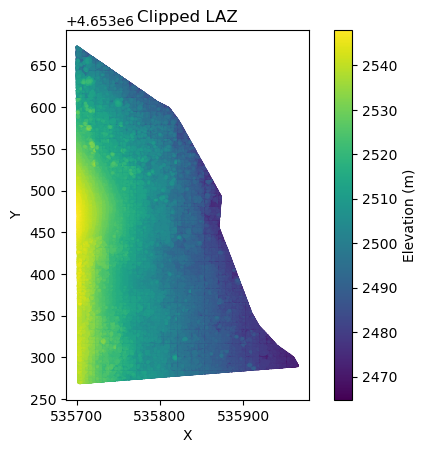

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

parcel.plot(ax=ax, facecolor="none", edgecolor="red")

sc = ax.scatter(clipped_las.x, clipped_las.y, c=clipped_las.z, s=1)

plt.colorbar(sc, ax=ax, label="Elevation (m)")
ax.set_title("Clipped LAZ")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

In [ ]:
import numpy as np
# check that we have correct classifications
print(np.unique(clipped_las.classification))
ground_mask = clipped_las.classification == 2


[1 2 7]


In [20]:
import numpy as np
from scipy.stats import binned_statistic_2d
import rasterio
from rasterio.transform import from_origin
# 1) keep only ground points
ground_mask = clipped_las.classification == 2

x = clipped_las.x[ground_mask]
y = clipped_las.y[ground_mask]
z = clipped_las.z[ground_mask]

print("Number of ground points:", len(z))

# 2) choose raster cell size
cell_size = 1.0  # meters

# 3) define raster extent
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

# make edges that align to cell size
x_edges = np.arange(xmin, xmax + cell_size, cell_size)
y_edges = np.arange(ymin, ymax + cell_size, cell_size)

Number of ground points: 113419
